#**Object Detection using TensorFlow (Classification and Localization)**

#**1. Importing Required Libraries**

Installed and imported the essential Python libraries and TensorFlow dependencies required for the object detection project. These libraries provided the necessary functionalities for numerical computations, data visualization, image processing, dataset management, and deep learning model development. Additionally, I updated the required packages to ensure compatibility and establish a stable environment for implementing the TensorFlow-based object detection pipeline.

In [1]:
import os

In [2]:
!pip install numpy
!pip install matplotlib
!pip install tensorflow
!pip install Pillow
!pip install tensorflow-datasets
!pip install --upgrade protobuf


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image, PIL.ImageFont, PIL.ImageDraw
import tensorflow as tf
import tensorflow_datasets as tfds

#**2. Importing Visualization Utilities**

I imported and implemented the visualization utilities required for the object detection pipeline. These utilities were used to process the dataset, render bounding boxes on images, visualize the predicted and ground truth annotations, generate sample digit images, and plot the model's training and validation metrics. Collectively, these functions facilitated the effective interpretation, validation, and qualitative evaluation of the object detection model throughout the project.

In [4]:
im_width = 128
im_height = 128
use_normalized_coordinates = True

In [5]:
def draw_bounding_boxes_on_image_array(image,boxes,color=[],thickness=1,display_str_list=()):
  image_pil = PIL.Image.fromarray(image)
  rbg_image = PIL.Image.new("RGB",image_pil.size)
  rbg_image.paste(image_pil)
  draw_bounding_boxes_on_image(rbg_image,boxes,color=color,thickness=thickness,display_str_list=display_str_list)
  return np.array(rbg_image)

def draw_bounding_boxes_on_image(image,boxes,color=[],thickness=1,display_str_list=()):
  boxes_shape = boxes.shape
  if not boxes_shape:
    return
  if len(boxes_shape) != 2 or boxes_shape[-1] != 4:
    raise ValueError('Input must be of size [N,4]')
  for i in range(boxes_shape[0]):
    draw_bounding_box_on_image(image,boxes[i,0],boxes[i,1],boxes[i,2],boxes[i,3],color[i],thickness,display_str_list[i])

def draw_bounding_box_on_image(image,ymin,xmin,ymax,xmax,color='red',thickness=1,use_normalized_coordinates = True):
  draw = PIL.ImageDraw.Draw(image)
  im_width,im_height = image.size
  if use_normalized_coordinates:
    (left,right,top,bottom) = (xmin*im_width,xmax*im_width,ymin*im_height,ymax*im_height)
  else:
    (left,right,top,bottom) = (xmin,xmax,ymin,ymax)
  draw.line([(left,top),(left,bottom),(right,bottom),(right,top),(left,top)],fill=color,width=thickness)

In [6]:
def dataset_to_numpy_util(training_dataset,validation_dataset,N):

  train_data = training_dataset.take(1).get_single_element()
  validation_data = validation_dataset.take(1).get_single_element()

  training_digits = train_data[0].numpy()
  training_labels = train_data[1][0].numpy()
  training_bboxes = train_data[1][1].numpy()

  validation_digits = validation_data[0].numpy()
  validation_labels = validation_data[1][0].numpy()
  validation_bboxes = validation_data[1][1].numpy()

  training_labels = np.argmax(training_labels, axis=1)
  validation_labels = np.argmax(validation_labels, axis=1)

  return (training_digits,training_labels,training_bboxes),(validation_digits,validation_labels,validation_bboxes)

In [7]:
MATPLOTLIB_FONT_DIR = os.path.join(os.path.dirname(plt.__file__), "mpl-data/fonts/ttf")
def create_digits_from_local_fonts(n):
  font_labels = []
  img = PIL.Image.new('LA', (75*n, 75), color = (0, 255))
  font1 = PIL.ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, 'DejaVuSansMono-Oblique.ttf'), 25)
  font2 = PIL.ImageFont.truetype(os.path.join(MATPLOTLIB_FONT_DIR, 'STIXGeneral.ttf'), 25)
  d = PIL.ImageDraw.Draw(img)
  for i in range(n):
    font_labels.append(i % 10)
    d.text((7+i*75, 0 if i<10 else -4), str(i*10), fill = (255, 255), font = font1 if i<10 else font2)
  font_digits = np.array(img.getdata(), np.float32)[:, 0] / 255.0
  font_digits = np.reshape(np.stack(np.split(np.reshape(font_digits), [75, 75*n], n ,axis=1), axis = 0 ) [n , 75*75])
  return font_digits, font_labels

In [8]:
def display_digits_with_boxes(digits, predictions, pred_bboxes, labels, bboxes, iou, title, indexes=None):
  n=3

  if indexes is None:
    indexes = np.random.choice(len(predictions),size=n)
  else:
    n = len(indexes)

  n_digits = digits[indexes]
  n_predictions = predictions[indexes]
  n_labels = labels[indexes]

  n_iou = []
  if len(iou) > 0:
    n_iou = iou[indexes]
  if len(pred_bboxes) > 0:
    n_pred_bboxes = pred_bboxes[indexes]
  if len(bboxes) > 0:
    n_bboxes = bboxes[indexes]

  n_digits = n_digits * 255.0
  n_digits = n_digits.reshape(n, 75, 75)
  fig = plt.figure(figsize=(20, 4))
  plt.title(title)
  plt.xticks([])
  plt.yticks([])

  for i in range(n):
    ax = fig.add_subplot(1, n, i+1)
    bboxes_to_plot = []
    colors_to_plot = []
    display_strings_to_plot = []

    if len(pred_bboxes) > i:
      bboxes_to_plot.append(list(n_pred_bboxes[i]))
      colors_to_plot.append('red')
      display_strings_to_plot.append('Pred')

    if len(bboxes) > i:
      bboxes_to_plot.append(list(n_bboxes[i]))
      colors_to_plot.append('green')
      display_strings_to_plot.append('True')

    if len(bboxes_to_plot) > 0:
      bboxes_to_plot = np.asarray(bboxes_to_plot).reshape([-1, 4])
    else:
      bboxes_to_plot = np.empty((0, 4))


    img_to_draw = draw_bounding_boxes_on_image_array(image=n_digits[i],boxes=bboxes_to_plot,color=colors_to_plot,display_str_list=display_strings_to_plot)

    plt.xlabel(f"{n_predictions[i]}\nIoU: {n_iou[i][0]:.6f}" if len(iou) > i else str(n_predictions[i]))
    plt.xticks([])
    plt.yticks([])

    if n_predictions[i] != n_labels[i]:
      ax.xaxis.label.set_color('red')

    plt.imshow(img_to_draw)
    if len(iou) > i:
      color = "black"
      if(n_iou[i][0] < iou_threshold):
        color = "red"
      ax.text(0.2, -0.3, "", color=color, transform=ax.transAxes)

In [9]:
def plot_metrics(metric_name, title):
  plt.title(title)
  plt.plot(history.history[metric_name], color='blue', label = metric_name)
  plt.plot(history.history['val_' + metric_name], color='green', label = 'val_' + metric_name)

#**3. Loading and Preprocessing the Dataset**

I loaded the MNIST dataset and performed the necessary preprocessing to prepare it for the object detection task. The preprocessing pipeline included resizing and normalizing the input images, generating normalized bounding box coordinates through random padding, and encoding the class labels. Furthermore, I constructed optimized training and validation data pipelines using TensorFlow's data API and visualized the processed images with their corresponding labels and bounding boxes to verify the correctness of the preprocessing stage before model training.

In [10]:
strategy = tf.distribute.get_strategy()
strategy.num_replicas_in_sync

1

In [11]:
BATCH_SIZE = 64

In [12]:
def read_image_tfds(image, label):

  image = tf.image.resize(image, (28, 28))
  image = tf.reshape(image, (28, 28, 1))
  image = tf.cast(image, tf.float32) / 255.0

  padded_height = 75
  padded_width = 75
  offset_y = tf.random.uniform((), 0, padded_height - 28 + 1, dtype=tf.int32)
  offset_x = tf.random.uniform((), 0, padded_width - 28 + 1, dtype=tf.int32)

  image = tf.image.pad_to_bounding_box(image, offset_y, offset_x, padded_height, padded_width)

  ymin_normalized = tf.cast(offset_y, tf.float32) / tf.cast(padded_height, tf.float32)
  xmin_normalized = tf.cast(offset_x, tf.float32) / tf.cast(padded_width, tf.float32)
  ymax_normalized = tf.cast(offset_y + 28, tf.float32) / tf.cast(padded_height, tf.float32)
  xmax_normalized = tf.cast(offset_x + 28, tf.float32) / tf.cast(padded_width, tf.float32)

  return image, (tf.one_hot(label, 10), [ymin_normalized, xmin_normalized, ymax_normalized, xmax_normalized])

In [13]:
def get_training_dataset():
  with strategy.scope():
    dataset = tfds.load("mnist", split="train", as_supervised=True, try_gcs=True)
    dataset = dataset.map(read_image_tfds, num_parallel_calls = 16)
    dataset = dataset.shuffle(5000, reshuffle_each_iteration=True)
    dataset = dataset.repeat()
    dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
    dataset = dataset.prefetch(-1)
  return dataset

In [14]:
def get_validation_dataset():
  with strategy.scope():
    dataset = tfds.load("mnist", split="train", as_supervised=True, try_gcs=True)
    dataset = dataset.map(read_image_tfds, num_parallel_calls = 16)
    dataset = dataset.batch(10000, drop_remainder=True)
    dataset = dataset.repeat()
  return dataset

In [15]:
with strategy.scope():
  training_dataset = get_training_dataset()
  validation_dataset = get_validation_dataset()

In [16]:
(training_digits,training_labels,training_bboxes),(validation_digits,validation_labels,validation_bboxes) = dataset_to_numpy_util(training_dataset,validation_dataset,10)

In [17]:
###Visualise Data

In [18]:
iou_threshold = 0.5

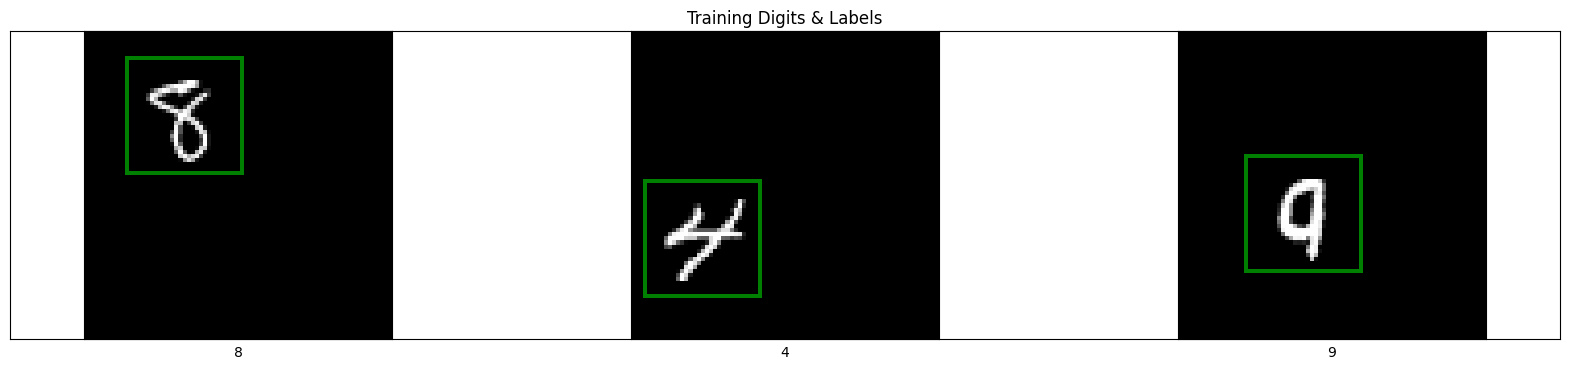

In [19]:
display_digits_with_boxes(training_digits, training_labels, np.array([]), training_labels, training_bboxes, np.array([]), "Training Digits & Labels")

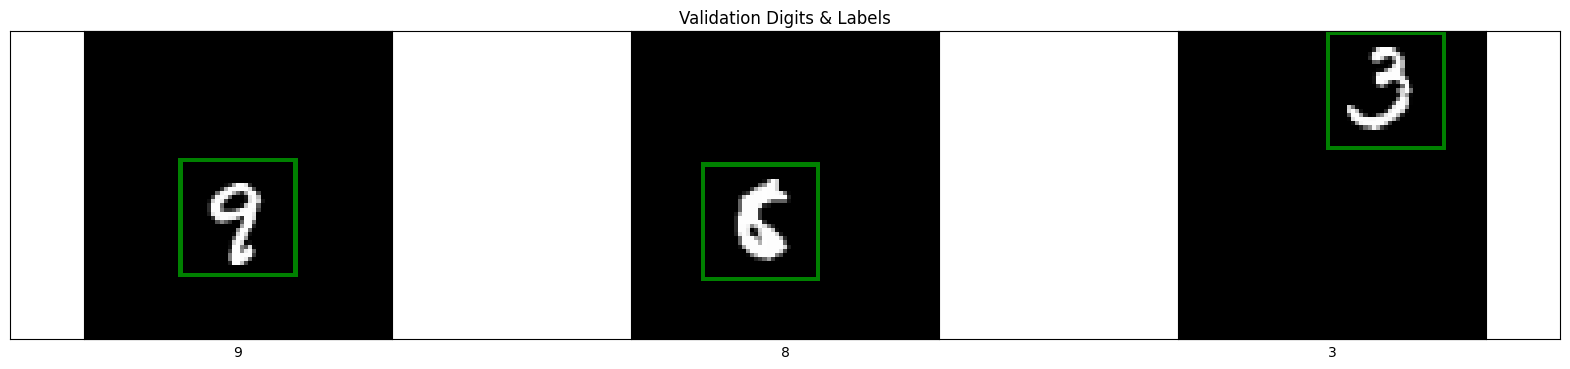

In [20]:
display_digits_with_boxes(validation_digits,validation_labels, np.array([]), validation_labels, validation_bboxes, np.array([]), "Validation Digits & Labels")

#**4. Define the Network**

I designed and implemented a custom Convolutional Neural Network (CNN) architecture using the TensorFlow Functional API. The network comprises multiple convolutional and pooling layers for feature extraction, followed by dense layers for high-level feature learning. Separate output branches were defined for object classification and bounding box regression, enabling the model to perform both tasks simultaneously. Finally, the model was compiled using the Adam optimizer with appropriate loss functions and evaluation metrics, and the network architecture was verified through the generated model summary.

In [40]:
def feature_extractor(inputs):
  x = tf.keras.layers.Conv2D(16, activation='relu', kernel_size=3)(inputs)
  x = tf.keras.layers.AveragePooling2D((2, 2))(x)


  x = tf.keras.layers.Conv2D(32, activation='relu', kernel_size=3)(x)
  x = tf.keras.layers.AveragePooling2D((2, 2))(x)

  x = tf.keras.layers.Conv2D(64, activation='relu', kernel_size=3)(x)
  x = tf.keras.layers.AveragePooling2D((2, 2))(x)

  return x

In [22]:
def dense_layers(inputs):
  x = tf.keras.layers.Flatten()(inputs)
  x = tf.keras.layers.Dense(128, activation='relu')(x)
  return x

In [23]:
def classifier(inputs):
  classification_output = tf.keras.layers.Dense(10, activation='softmax', name='classification')(inputs)
  return classification_output

In [24]:
def bounding_box_regression(inputs):
  bounding_box_regression_output = tf.keras.layers.Dense(4, name='bounding_box')(inputs)
  return bounding_box_regression_output

In [25]:
def final_model(inputs):
  feature_cnn = feature_extractor(inputs)
  dense_output = dense_layers(feature_cnn)

  classification_output = classifier(dense_output)
  bounding_box_output = bounding_box_regression(dense_output)

  model = tf.keras.Model(inputs=inputs, outputs=[classification_output, bounding_box_output])
  return model

In [26]:
def define_and_compile_model(inputs):
  model = final_model(inputs)

  model.compile(optimizer='adam',
                loss={'classification': 'categorical_crossentropy',
                      'bounding_box': 'mse'},
                metrics={'classification': 'accuracy',
                         'bounding_box': 'mse'})
  return model

In [43]:
with strategy.scope():
  inputs = tf.keras.Input(shape=(75, 75, 1))
  model = define_and_compile_model(inputs)
  model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 75, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 73, 73,    │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 36, 36,    │          0 │ conv2d[0][0]      │
│ (AveragePooling2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 34, 34,    │      4,640 │ average_pooling2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_1 │ (None, 17, 17,    │          0 │ conv2d_1[0][0]    │
│ (AveragePooling2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 15, 15,    │     18,496 │ average_pooling2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 7, 7, 64)  │          0 │ conv2d_2[0][0]    │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 10)        │      1,290 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bounding_box        │ (None, 4)         │        516 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 426,638 (1.63 MB)

 Trainable params: 426,638 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

#**5. Training and Validating the Model**

I trained the object detection model using the preprocessed training dataset while validating its performance on the validation dataset over multiple epochs. Upon completion of training, I evaluated the model using key performance metrics, including Classification Accuracy, Classification Loss, and Bounding Box Mean Squared Error (MSE). Furthermore, I visualized these metrics to monitor the learning progress and computed the Intersection over Union (IoU) to assess the localization accuracy. Finally, I compared the predicted object classes and bounding boxes with the ground truth annotations to qualitatively evaluate the overall detection performance.

In [28]:
EPOCHS = 20
steps_per_epochs = 60000 //BATCH_SIZE
validation_steps = 1

history = model.fit(training_dataset, steps_per_epoch=steps_per_epochs, validation_data = validation_dataset, validation_steps=1, epochs=EPOCHS)

loss, classification_loss, classification_acc, bounding_box_loss, bounding_box_mse = model.evaluate(validation_dataset, steps=1)
print("\n------------------------\n")
print("Validation Accuracy: ", classification_acc)
print("\n------------------------\n")

Epoch 1/20
937/937 ━━━━━━━━━━━━━━━━━━━━ 279s 287ms/step - bounding_box_loss: 0.0143 - bounding_box_mse: 0.0143 - classification_accuracy: 0.6549 - classification_loss: 0.9761 - loss: 0.9904 - val_bounding_box_loss: 0.0083 - val_bounding_box_mse: 0.0083 - val_classification_accuracy: 0.8943 - val_classification_loss: 0.3555 - val_loss: 0.3638
Epoch 2/20
937/937 ━━━━━━━━━━━━━━━━━━━━ 268s 287ms/step - bounding_box_loss: 0.0059 - bounding_box_mse: 0.0059 - classification_accuracy: 0.9190 - classification_loss: 0.2644 - loss: 0.2703 - val_bounding_box_loss: 0.0053 - val_bounding_box_mse: 0.0053 - val_classification_accuracy: 0.9111 - val_classification_loss: 0.2875 - val_loss: 0.2928
Epoch 3/20
937/937 ━━━━━━━━━━━━━━━━━━━━ 255s 272ms/step - bounding_box_loss: 0.0034 - bounding_box_mse: 0.0034 - classification_accuracy: 0.9409 - classification_loss: 0.1925 - loss: 0.1959 - val_bounding_box_loss: 0.0030 - val_bounding_box_mse: 0.0030 - val_classification_accuracy: 0.9490 - val_classification_

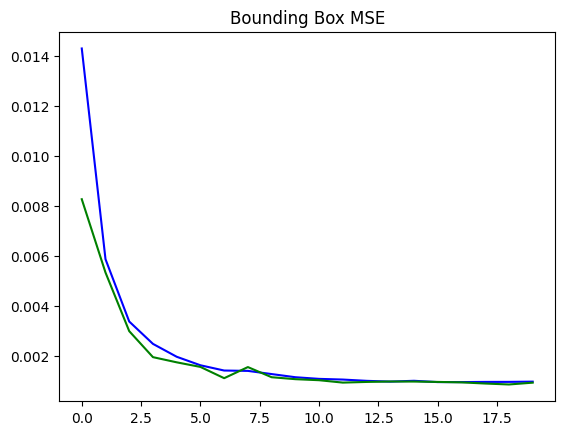

In [29]:
plot_metrics("bounding_box_mse", "Bounding Box MSE")

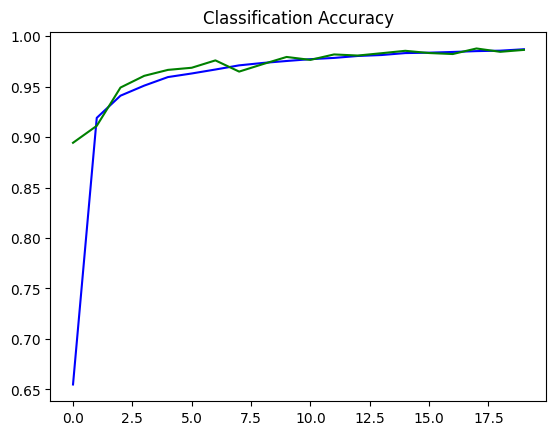

In [30]:
plot_metrics("classification_accuracy", "Classification Accuracy")

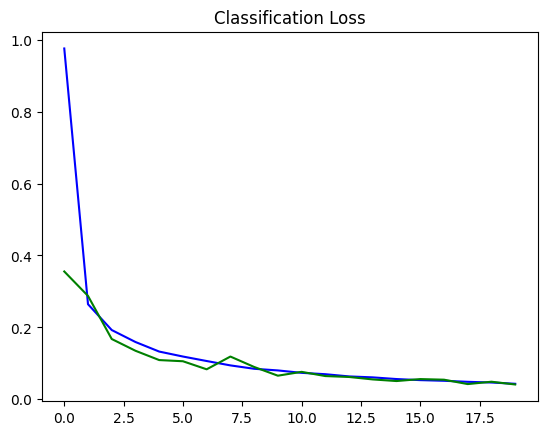

In [31]:
plot_metrics("classification_loss", "Classification Loss")

In [32]:
def intersection_over_union(pred_box, true_box):
  xmin_pred, ymin_pred, xmax_pred, ymax_pred = np.split(pred_box, 4, axis = 1)
  xmin_true, ymin_true, xmax_true, ymax_true = np.split(true_box, 4, axis = 1)

  smoothing_factor = 1e-10
  xmin_overlap = np.maximum(xmin_pred, xmin_true)
  xmax_overlap = np.minimum(xmax_pred, xmax_true)
  ymin_overlap = np.maximum(ymin_pred, ymin_true)
  ymax_overlap = np.minimum(ymax_pred, ymax_true)

  pred_box_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
  true_box_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)

  overlap_area = np.maximum((xmax_overlap - xmin_overlap), 0) * np.maximum((ymax_overlap - ymin_overlap), 0)
  union_area = (pred_box_area + true_box_area) - overlap_area

  iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)
  return iou

In [33]:
prediction = model.predict(validation_digits, batch_size = 64)

predicted_labels = np.argmax(prediction[0], axis = 1)
predicted_bboxes = prediction[1]

157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step


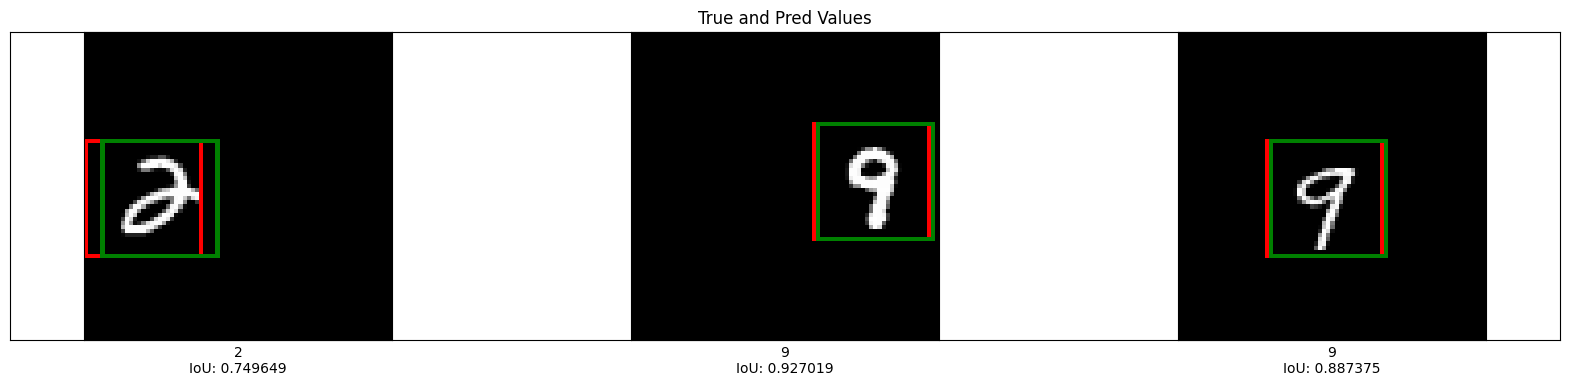

In [34]:
iou = intersection_over_union(predicted_bboxes, validation_bboxes)

iou_threshold = 0.6

display_digits_with_boxes(validation_digits, predicted_labels, predicted_bboxes, validation_labels, validation_bboxes, iou, "True and Pred Values")

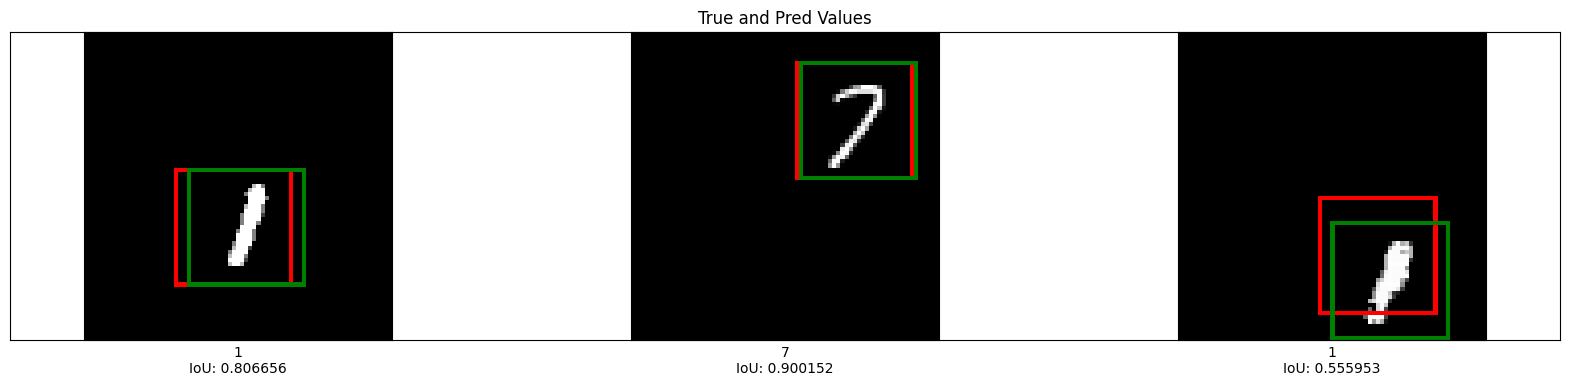

In [35]:
display_digits_with_boxes(validation_digits, predicted_labels, predicted_bboxes, validation_labels, validation_bboxes, iou, "True and Pred Values")